In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

In [5]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv


In [6]:
df = pd.read_csv('/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv')

In [7]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [8]:
df.shape

(50000, 16)

In [9]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [14]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv')
X = df[
[
'Pre_Semester_GPA',
'Weekly_GenAI_Hours',
'Traditional_Study_Hours',
'Tool_Diversity',
'Perceived_AI_Dependency',
'Anxiety_Level_During_Exams',
'Skill_Retention_Score'
]
]

y = df['Post_Semester_GPA']

In [15]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [19]:
df.shape

(50000, 16)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
X_train

array([[ 1.33554582,  0.50146885, -0.87031928, ..., -0.27732951,
        -1.05774386,  0.43356484],
       [ 1.26673575, -0.88144737,  0.04328678, ..., -0.27732951,
        -1.05774386, -2.23984713],
       [-0.44726049, -0.58070838,  0.2426542 , ..., -1.37517504,
        -1.05774386, -0.38705443],
       ...,
       [ 1.37307858, -0.02633411,  0.39750269, ...,  0.27159326,
         0.33900182,  0.76783544],
       [-0.5139854 ,  0.98820705, -0.82580034, ...,  1.91836157,
         2.20132939,  0.67749204],
       [-0.64326493, -1.00584944, -1.43938746, ..., -0.27732951,
        -1.05774386, -0.20787335]])

In [27]:
import numpy as np


class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs


    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0


        for i in range(self.epochs):

            y_pred = np.dot(X, self.weights) + self.bias


            dw = (1/n_samples) * np.dot(
                X.T,
                (y_pred-y)
            )

            db = (1/n_samples) * np.sum(
                y_pred-y
            )


            self.weights -= self.lr * dw

            self.bias -= self.lr * db



    def predict(self,X):

        return np.dot(X,self.weights)+self.bias

In [28]:
model = LinearRegressionGD(
    learning_rate=0.01,
    epochs=1000
)


model.fit(
    X_train,
    y_train
)

In [29]:
X_train

array([[ 1.33554582,  0.50146885, -0.87031928, ..., -0.27732951,
        -1.05774386,  0.43356484],
       [ 1.26673575, -0.88144737,  0.04328678, ..., -0.27732951,
        -1.05774386, -2.23984713],
       [-0.44726049, -0.58070838,  0.2426542 , ..., -1.37517504,
        -1.05774386, -0.38705443],
       ...,
       [ 1.37307858, -0.02633411,  0.39750269, ...,  0.27159326,
         0.33900182,  0.76783544],
       [-0.5139854 ,  0.98820705, -0.82580034, ...,  1.91836157,
         2.20132939,  0.67749204],
       [-0.64326493, -1.00584944, -1.43938746, ..., -0.27732951,
        -1.05774386, -0.20787335]])

In [30]:
prediction = model.predict(X_test)

In [31]:
from sklearn.metrics import mean_squared_error


mse = mean_squared_error(
    y_test,
    prediction
)

print(mse)

0.028178256519269224


In [32]:
rmse = np.sqrt(mse)

print(rmse)

0.16786380348148086


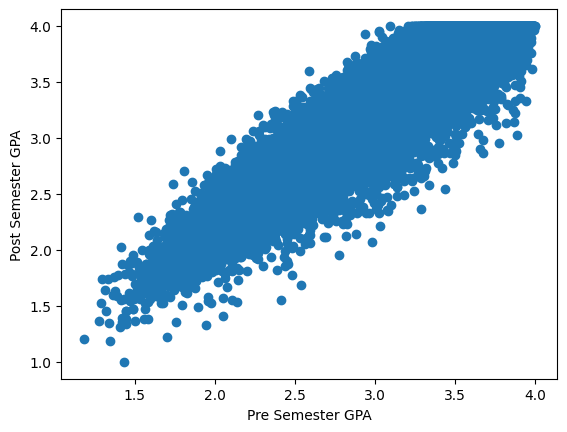

In [34]:
import matplotlib.pyplot as plt

plt.scatter(
    df['Pre_Semester_GPA'],
    df['Post_Semester_GPA']
)

plt.xlabel("Pre Semester GPA")
plt.ylabel("Post Semester GPA")

plt.show()

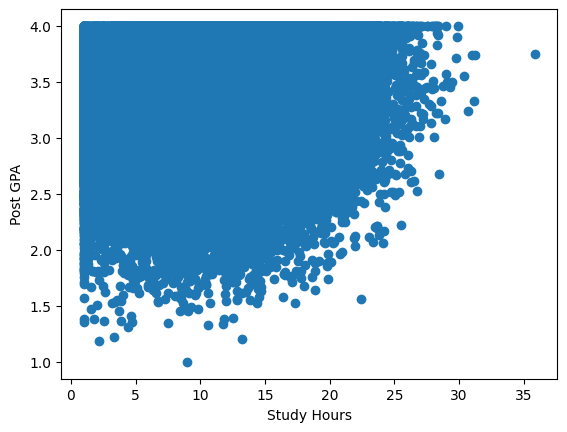

In [35]:
plt.scatter(
    df['Traditional_Study_Hours'],
    df['Post_Semester_GPA']
)

plt.xlabel("Study Hours")
plt.ylabel("Post GPA")

plt.show()

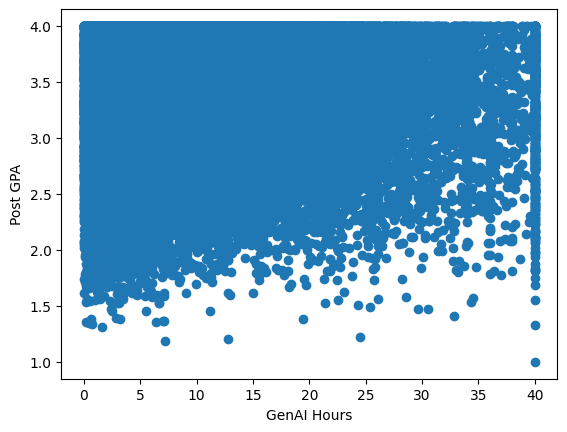

In [36]:
plt.scatter(
    df['Weekly_GenAI_Hours'],
    df['Post_Semester_GPA']
)

plt.xlabel("GenAI Hours")
plt.ylabel("Post GPA")

plt.show()

In [37]:
df[
[
'Pre_Semester_GPA',
'Traditional_Study_Hours',
'Weekly_GenAI_Hours',
'Post_Semester_GPA'
]
].corr()

,Pre_Semester_GPA,Traditional_Study_Hours,Weekly_GenAI_Hours,Post_Semester_GPA
Pre_Semester_GPA,1.000000,-0.004620,-0.001084,0.926781
Traditional_Study_Hours,-0.004620,1.000000,-0.157368,0.137653
Weekly_GenAI_Hours,-0.001084,-0.157368,1.000000,-0.018600
Post_Semester_GPA,0.926781,0.137653,-0.018600,1.000000


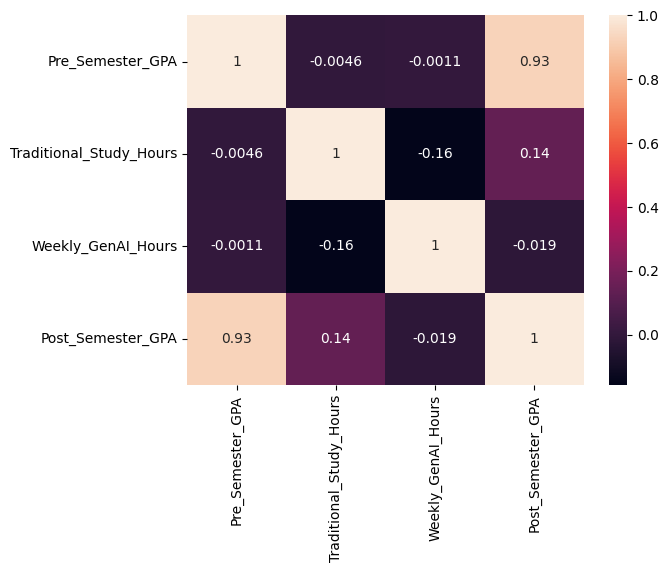

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(
    df[
    [
    'Pre_Semester_GPA',
    'Traditional_Study_Hours',
    'Weekly_GenAI_Hours',
    'Post_Semester_GPA'
    ]
    ].corr(),
    annot=True
)

plt.show()

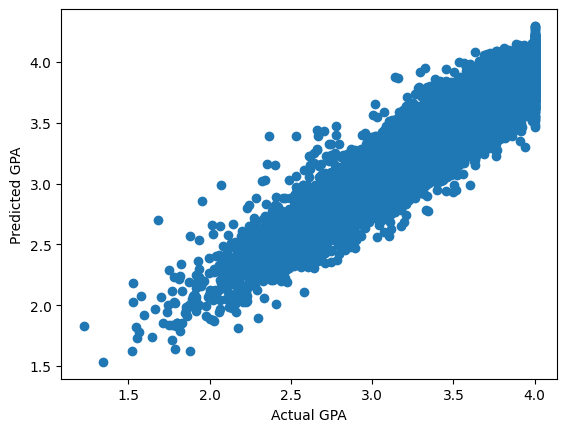

In [39]:
plt.scatter(
    y_test,
    prediction
)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")

plt.show()